# **Sistem Rekomendasi Destinasi Wisata di Yogyakarta**
# 0.Import Library

In [66]:
import kagglehub
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers

# 1.Data Understanding
**Loading Dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download('aprabowo/indonesia-tourism-destination', output_dir='dataset')

print('Path to dataset files:', path)

Path to dataset files: dataset


In [3]:
package = pd.read_csv('dataset/package_tourism.csv')
rating = pd.read_csv('dataset/tourism_rating.csv')
place = pd.read_csv('dataset/tourism_with_id.csv')
user = pd.read_csv('dataset/user.csv')

**Univariate Data Analysis**

In [4]:
rating.head(1)

,User_Id,Place_Id,Place_Ratings
0,1,179,3


In [5]:
rating.info()
print('Jumlah Data Rating: {}'.format(len(rating.Place_Id.unique())))

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB
Jumlah Data Rating: 437


In [6]:
rating.describe()

,User_Id,Place_Id,Place_Ratings
count,10000.000000,10000.000000,10000.000000
mean,151.292700,219.416400,3.066500
std,86.137374,126.228335,1.379952
min,1.000000,1.000000,1.000000
25%,77.000000,108.750000,2.000000
50%,151.000000,220.000000,3.000000
75%,226.000000,329.000000,4.000000
max,300.000000,437.000000,5.000000


In [7]:
place.head(1)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1


In [8]:
place = place.drop(['Time_Minutes', 'Unnamed: 11', 'Unnamed: 12'], axis=1)

In [9]:
place.info()
print('Jumlah Data Tempat: {}'.format(len(place.Place_Id.unique())))

<class 'pandas.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Place_Id     437 non-null    int64  
 1   Place_Name   437 non-null    str    
 2   Description  437 non-null    str    
 3   Category     437 non-null    str    
 4   City         437 non-null    str    
 5   Price        437 non-null    int64  
 6   Rating       437 non-null    float64
 7   Coordinate   437 non-null    str    
 8   Lat          437 non-null    float64
 9   Long         437 non-null    float64
dtypes: float64(3), int64(2), str(5)
memory usage: 34.3 KB
Jumlah Data Tempat: 437


In [10]:
place.describe()

,Place_Id,Price,Rating,Lat,Long
count,437.000000,437.000000,437.000000,437.000000,437.000000
mean,219.000000,24652.173913,4.442792,-7.095438,109.160142
std,126.295289,66446.374709,0.208587,0.727241,1.962848
min,1.000000,0.000000,3.400000,-8.197894,103.931398
25%,110.000000,0.000000,4.300000,-7.749590,107.578369
50%,219.000000,5000.000000,4.500000,-7.020524,110.237468
75%,328.000000,20000.000000,4.600000,-6.829411,110.431869
max,437.000000,900000.000000,5.000000,1.078880,112.821662


In [11]:
print("Nama Tempat: {}".format(place.Place_Name.unique()))

Nama Tempat: <StringArray>
[                         'Monumen Nasional',
                                  'Kota Tua',
                             'Dunia Fantasi',
         'Taman Mini Indonesia Indah (TMII)',
                  'Atlantis Water Adventure',
                   'Taman Impian Jaya Ancol',
                    'Kebun Binatang Ragunan',
                             'Ocean Ecopark',
                          'Pelabuhan Marina',
                              'Pulau Tidung',
 ...
            'Monumen Bambu Runcing Surabaya',
                        'House of Sampoerna',
                    'Atlantis Land Surabaya',
                      'Taman Hiburan Rakyat',
                               'Taman Mundu',
                       'Museum Mpu Tantular',
                             'Taman Bungkul',
          'Taman Air Mancur Menari Kenjeran',
              'Taman Flora Bratang Surabaya',
 'Gereja Perawan Maria Tak Berdosa Surabaya']
Length: 437, dtype: str


In [12]:
print('Nama Kota: {}'.format(place.City.unique()))

Nama Kota: <StringArray>
['Jakarta', 'Yogyakarta', 'Bandung', 'Semarang', 'Surabaya']
Length: 5, dtype: str


In [13]:
diy = place[place['City'] == 'Yogyakarta']
diy.head(1)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Coordinate,Lat,Long
84,85,Taman Pintar Yogyakarta,Taman Pintar Yogyakarta (bahasa Jawa: Hanacara...,Taman Hiburan,Yogyakarta,6000,4.5,"{'lat': -7.800671500000001, 'lng': 110.3676551}",-7.800671,110.367655


In [14]:
diy.describe()

,Place_Id,Price,Rating,Lat,Long
count,126.000000,126.000000,126.000000,126.000000,126.000000
mean,147.500000,19456.349206,4.466667,-7.890662,110.423022
std,36.517119,55219.055401,0.173897,0.166461,0.140273
min,85.000000,0.000000,4.000000,-8.197894,110.019826
25%,116.250000,2500.000000,4.400000,-8.011420,110.363687
50%,147.500000,5000.000000,4.500000,-7.816139,110.416944
75%,178.750000,10000.000000,4.600000,-7.793766,110.492845
max,210.000000,500000.000000,5.000000,-7.582920,110.720854


In [15]:
user.head(1)

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20


In [16]:
user.info()
print('Jumlah Data User: {}'.format(len(user.User_Id.unique())))

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   User_Id   300 non-null    int64
 1   Location  300 non-null    str  
 2   Age       300 non-null    int64
dtypes: int64(2), str(1)
memory usage: 7.2 KB
Jumlah Data User: 300


In [17]:
user.describe()

,User_Id,Age
count,300.000000,300.000000
mean,150.500000,28.700000
std,86.746758,6.393716
min,1.000000,18.000000
25%,75.750000,24.000000
50%,150.500000,29.000000
75%,225.250000,34.000000
max,300.000000,40.000000


In [18]:
# Menggabungkan data user dan data rating untuk mendapatkan tempat yang pernah dikunjungi oleh user. 
# dengan user_id sebagai key nya,
user_place = pd.merge(user, rating, on='User_Id', how='inner')
user_place.head

<bound method NDFrame.head of       User_Id               Location  Age  Place_Id  Place_Ratings
0           1  Semarang, Jawa Tengah   20       179              3
1           1  Semarang, Jawa Tengah   20       344              2
2           1  Semarang, Jawa Tengah   20         5              5
3           1  Semarang, Jawa Tengah   20       373              3
4           1  Semarang, Jawa Tengah   20       101              4
...       ...                    ...  ...       ...            ...
9995      300   Ponorogo, Jawa Timur   26       425              2
9996      300   Ponorogo, Jawa Timur   26        64              4
9997      300   Ponorogo, Jawa Timur   26       311              3
9998      300   Ponorogo, Jawa Timur   26       279              4
9999      300   Ponorogo, Jawa Timur   26       163              2

[10000 rows x 5 columns]>

In [19]:
# Menggabungkan data tempat dan rating untuk mendapatkan rating tempat yang sudah difilter di yogyakarta. 
# dengan place_id sebagai primary key nya.
rating_diy = pd.merge(rating, diy, on='Place_Id', how='inner')
rating_diy.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:ꦕꦤ...,Budaya,Yogyakarta,75000,4.6,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151
2,1,154,2,Pantai Ngrawe (Mesra),Kabupaten Gunungkidul jadi salah satu wilayah ...,Bahari,Yogyakarta,10000,4.5,"{'lat': -8.1333389, 'lng': 110.5537405}",-8.133339,110.553741
3,1,103,3,Tugu Pal Putih Jogja,"Tugu Yogyakarta (Jawa: , Tugu Ngayogyakarta) a...",Taman Hiburan,Yogyakarta,0,4.7,"{'lat': -7.782943699999998, 'lng': 110.3670548}",-7.782944,110.367055
4,1,208,5,Taman Sungai Mudal,"Taman Sungai Mudal, sebuah objek wisata alam t...",Cagar Alam,Yogyakarta,10000,4.6,"{'lat': -7.762813599999998, 'lng': 110.1161626}",-7.762814,110.116163


# 2.Data Preparation

In [20]:
missing = pd.DataFrame({
    'Missing': rating_diy.isna().sum(),
    'Persentase': (rating_diy.isna().sum() * 100 / len(rating_diy)).round(2)
})

missing

,Missing,Persentase
User_Id,0,0.0
Place_Id,0,0.0
Place_Ratings,0,0.0
Place_Name,0,0.0
Description,0,0.0
Category,0,0.0
City,0,0.0
Price,0,0.0
Rating,0,0.0
Coordinate,0,0.0


In [21]:
duplicated = rating_diy.duplicated()
print('Duplicated Rows: {}'.format(duplicated))

Duplicated Rows: 0       False
1       False
2       False
3       False
4       False
        ...  
2866    False
2867    False
2868    False
2869    False
2870    False
Length: 2871, dtype: bool


In [22]:
# Top 10 Rating tempat di Yogyakarta
top_10 = rating_diy[rating_diy['City'] == 'Yogyakarta'].value_counts().reset_index()[0:10]
top_10

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Coordinate,Lat,Long,count
0,9,204,2,Desa Wisata Pulesari,Desa Wisata Pulesari semakin menambah deretan ...,Taman Hiburan,Yogyakarta,0,4.4,"{'lat': -7.625880599999999, 'lng': 110.371698}",-7.625881,110.371698,2
1,49,90,1,Kampung Wisata Taman Sari,Taman Sari Yogyakarta atau Taman Sari Keraton ...,Taman Hiburan,Yogyakarta,5000,4.6,"{'lat': -7.8100673, 'lng': 110.3594581}",-7.810067,110.359458,2
2,68,138,1,Jogja Exotarium,"Di Yogyakarta, tepatnya di Sleman, ada satu te...",Taman Hiburan,Yogyakarta,20000,4.4,"{'lat': -7.7280356, 'lng': 110.3591712}",-7.728036,110.359171,2
3,77,167,5,Geoforest Watu Payung Turunan,Bagi para pemburu keindahan matahari terbit ya...,Cagar Alam,Yogyakarta,0,4.5,"{'lat': -7.974294, 'lng': 110.4364363}",-7.974294,110.436436,2
4,90,108,2,Embung Tambakboyo,Embung atau waduk Tambakboyo adalah konservasi...,Taman Hiburan,Yogyakarta,0,4.4,"{'lat': -7.756227000000001, 'lng': 110.4150131}",-7.756227,110.415013,2
5,103,198,1,Pantai Greweng,"Di Kabupaten Gunungkidul, tidak sulit memilih ...",Bahari,Yogyakarta,5000,4.6,"{'lat': -8.197864399999998, 'lng': 110.7186216}",-8.197864,110.718622,2
6,112,149,2,Goa Cerme,"Gua Cerme (bahasa Jawa: ꦒꦸꦮ​ꦕꦺꦂꦩꦺ, translit. G...",Cagar Alam,Yogyakarta,3000,4.4,"{'lat': -7.979441299999999, 'lng': 110.3803114}",-7.979441,110.380311,2
7,126,118,5,Museum Sonobudoyo Unit I,Museum Sonobudoyo adalah museum dan perpustaka...,Budaya,Yogyakarta,5000,4.6,"{'lat': -7.8024499, 'lng': 110.3639555}",-7.802450,110.363956,2
8,143,127,5,Blue Lagoon Jogja,Blue Lagoon adalah salah satu wisata air Jogja...,Taman Hiburan,Yogyakarta,10000,4.3,"{'lat': -7.7044358, 'lng': 110.45026}",-7.704436,110.450260,2
9,144,201,2,Pantai Kesirat,Pada umumnya pantai identik dengan pasirnya bu...,Bahari,Yogyakarta,5000,4.6,"{'lat': -8.096153500000002, 'lng': 110.4350483}",-8.096153,110.435048,2


C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_9004\3321528818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, x='Rating', y='Place_Name', palette='flare')


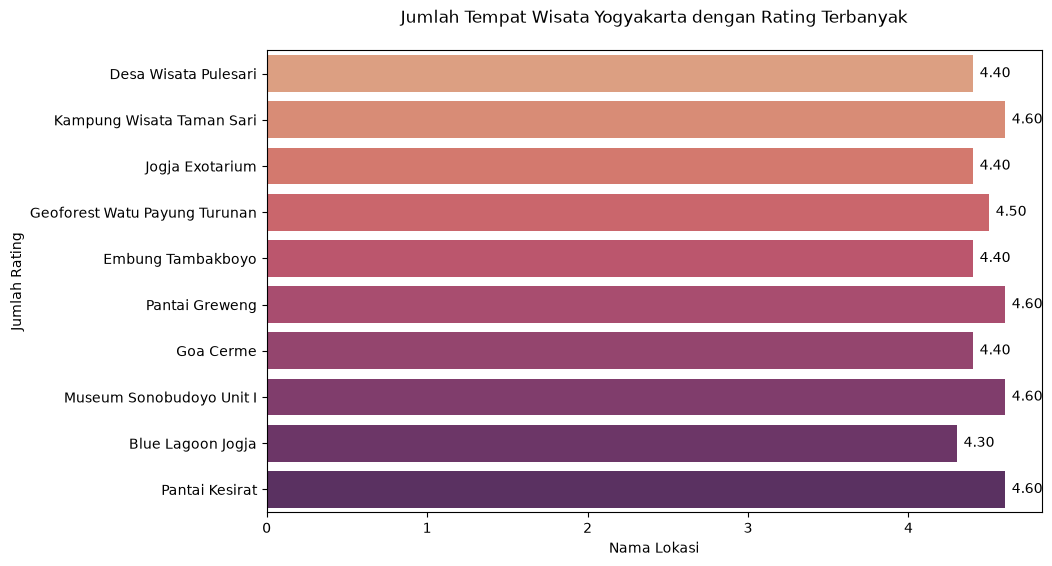

In [23]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_10, x='Rating', y='Place_Name', palette='flare')
plt.title('Jumlah Tempat Wisata Yogyakarta dengan Rating Terbanyak', pad=20)
plt.ylabel('Jumlah Rating')
plt.xlabel('Nama Lokasi')

for i, value in enumerate(top_10["Rating"]):
    ax.annotate(
        f"{value:.2f}",
        xy=(value, i),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
    )

plt.show()

C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_9004\2091792971.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=diy, palette='flare')


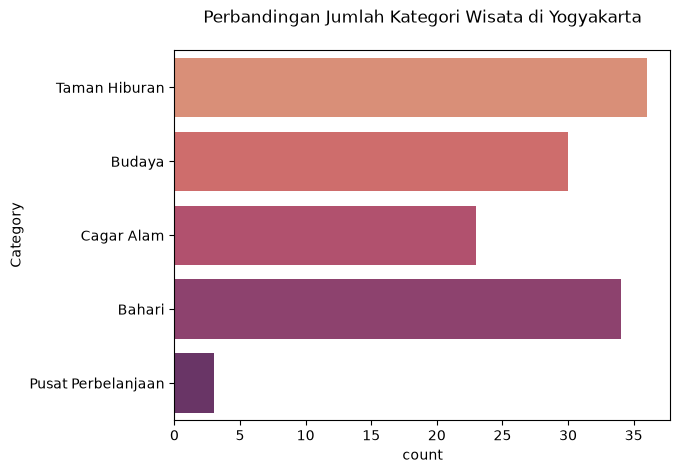

In [24]:
sns.countplot(y='Category', data=diy, palette='flare')
plt.title('Perbandingan Jumlah Kategori Wisata di Yogyakarta', pad=20)
plt.show()

In [25]:
rating_diy

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:ꦕꦤ...,Budaya,Yogyakarta,75000,4.6,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151
2,1,154,2,Pantai Ngrawe (Mesra),Kabupaten Gunungkidul jadi salah satu wilayah ...,Bahari,Yogyakarta,10000,4.5,"{'lat': -8.1333389, 'lng': 110.5537405}",-8.133339,110.553741
3,1,103,3,Tugu Pal Putih Jogja,"Tugu Yogyakarta (Jawa: , Tugu Ngayogyakarta) a...",Taman Hiburan,Yogyakarta,0,4.7,"{'lat': -7.782943699999998, 'lng': 110.3670548}",-7.782944,110.367055
4,1,208,5,Taman Sungai Mudal,"Taman Sungai Mudal, sebuah objek wisata alam t...",Cagar Alam,Yogyakarta,10000,4.6,"{'lat': -7.762813599999998, 'lng': 110.1161626}",-7.762814,110.116163
...,...,...,...,...,...,...,...,...,...,...,...,...
2866,300,107,2,Bangsal Pagelaran,Bangunan utama adalah Bangsal Pagelaran yang d...,Budaya,Yogyakarta,5000,4.6,"{'lat': -7.805284299999999, 'lng': 110.3642137}",-7.805284,110.364214
2867,300,193,5,Candi Sewu,Candi Sewu atau Manjusrighra (Hanacaraka:ꦕꦤ꧀ꦝꦶ...,Budaya,Yogyakarta,50000,4.6,"{'lat': -7.7439217, 'lng': 110.4929095}",-7.743922,110.492909
2868,300,108,5,Embung Tambakboyo,Embung atau waduk Tambakboyo adalah konservasi...,Taman Hiburan,Yogyakarta,0,4.4,"{'lat': -7.756227000000001, 'lng': 110.4150131}",-7.756227,110.415013
2869,300,103,5,Tugu Pal Putih Jogja,"Tugu Yogyakarta (Jawa: , Tugu Ngayogyakarta) a...",Taman Hiburan,Yogyakarta,0,4.7,"{'lat': -7.782943699999998, 'lng': 110.3670548}",-7.782944,110.367055


In [26]:
diy_new = diy[['Place_Id', 'Place_Name', 'Category']]

In [27]:
diy_new.sample(5)

,Place_Id,Place_Name,Category
203,204,Desa Wisata Pulesari,Taman Hiburan
142,143,Seribu Batu Songgo Langit,Cagar Alam
205,206,Wisata Kaliurang,Cagar Alam
168,169,Puncak Segoro,Cagar Alam
131,132,Air Terjun Kedung Pedut,Cagar Alam


In [28]:
tfidfvec = TfidfVectorizer()
tfidfvec.fit(diy_new['Category'])
tfidfvec.get_feature_names_out()

array(['alam', 'bahari', 'budaya', 'cagar', 'hiburan', 'perbelanjaan',
       'pusat', 'taman'], dtype=object)

In [29]:
tfidf_matrix = tfidfvec.fit_transform(diy_new['Category'])
tfidf_matrix.shape

(126, 8)

# 3.Modeling

**Model Development dengna Content Based Filtering**

In [30]:
pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidfvec.get_feature_names_out(),
    index=diy_new.Place_Name,
).sample(8, axis=1).sample(10, axis=0)

,perbelanjaan,taman,budaya,bahari,cagar,alam,pusat,hiburan
Place_Name,,,,,,,,
Pantai Pulang Sawal,0.0,0.000000,0.0,1.0,0.000000,0.000000,0.0,0.000000
Pantai Parangtritis,0.0,0.000000,0.0,1.0,0.000000,0.000000,0.0,0.000000
Green Village Gedangsari,0.0,0.707107,0.0,0.0,0.000000,0.000000,0.0,0.707107
Ledok Sambi,0.0,0.000000,0.0,0.0,0.707107,0.707107,0.0,0.000000
Hutan Pinus Asri,0.0,0.000000,0.0,0.0,0.707107,0.707107,0.0,0.000000
Taman Pintar Yogyakarta,0.0,0.707107,0.0,0.0,0.000000,0.000000,0.0,0.707107
Alun-alun Utara Keraton Yogyakarta,0.0,0.000000,1.0,0.0,0.000000,0.000000,0.0,0.000000
Museum Ullen Sentalu,0.0,0.000000,1.0,0.0,0.000000,0.000000,0.0,0.000000
Gembira Loka Zoo,0.0,0.000000,0.0,0.0,0.707107,0.707107,0.0,0.000000


In [32]:
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim

array([[1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 1., 1.]], shape=(126, 126))

In [48]:
cosine_sim_df = pd.DataFrame(cosine_sim, index=diy_new['Place_Name'], columns=diy_new['Place_Name'])
print('Shape: {}'.format(cosine_sim_df.shape))

cosine_sim_df

Shape: (126, 126)


Place_Name,Taman Pintar Yogyakarta,Keraton Yogyakarta,Sindu Kusuma Edupark (SKE),Museum Benteng Vredeburg Yogyakarta,De Mata Museum Jogja,Kampung Wisata Taman Sari,Situs Warungboto,Nol Kilometer Jl.Malioboro,Gembira Loka Zoo,Sumur Gumuling,...,Pantai Kesirat,Pantai Ngandong,Galaxy Waterpark Jogja,Desa Wisata Pulesari,Desa Wisata Tembi,Wisata Kaliurang,Heha Sky View,Taman Sungai Mudal,Pantai Sanglen,Pantai Congot
Place_Name,,,,,,,,,,,,,,,,,,,,,
Taman Pintar Yogyakarta,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Keraton Yogyakarta,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Sindu Kusuma Edupark (SKE),1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Museum Benteng Vredeburg Yogyakarta,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
De Mata Museum Jogja,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wisata Kaliurang,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Heha Sky View,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
Taman Sungai Mudal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [49]:
cosine_sim_df.sample(8, axis=1).sample(10, axis=0)

Place_Name,Bangsal Pagelaran,Pantai Ngrawe (Mesra),Bunker Kaliadem Merapi,Lava Bantal,Green Village Gedangsari,Wisata Kaliurang,Air Terjun Kedung Pedut,Taman Budaya Yogyakarta
Place_Name,,,,,,,,
Pasar Kebon Empring Bintaran,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Candi Donotirto,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Monumen Sanapati,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Pantai Pulang Sawal,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Goa Pindul,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
Goa Cerme,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
Bentara Budaya Yogyakarta (BBY),1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Gumuk Pasir Parangkusumo,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Watu Goyang,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [50]:
def destinatiion_recommendations(Place_Name, similarity_data=cosine_sim_df, items=diy_new[['Place_Name', 'Category']], k=5):
    index = similarity_data.loc[:,Place_Name].to_numpy().argpartition(range(-1, -k, -1))
    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    closest = closest.drop(Place_Name, errors='ignore')
    return pd.DataFrame(closest).merge(items).head(k)

In [51]:
diy_new[diy_new.Place_Name.eq('Pantai Sanglen')]

,Place_Id,Place_Name,Category
208,209,Pantai Sanglen,Bahari


In [52]:
destinatiion_recommendations('Pantai Sanglen')

,Place_Name,Category
0,Pantai Congot,Bahari
1,Pantai Sundak,Bahari
2,Pantai Depok Jogja,Bahari
3,Hutan Mangrove Kulon Progo,Bahari
4,Pantai Sadranan,Bahari


**Model Development dengan Collaborative Filtering**

In [53]:
rating

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4
...,...,...,...
9995,300,425,2
9996,300,64,4
9997,300,311,3
9998,300,279,4


In [55]:
user_ids = rating['User_Id'].unique().tolist()
print("list userID: ", user_ids)

list userID:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219

In [56]:
# Melakukan encoding userID
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)
 
# Melakukan proses encoding angka ke ke userID
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

encoded userID :  {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23, 25: 24, 26: 25, 27: 26, 28: 27, 29: 28, 30: 29, 31: 30, 32: 31, 33: 32, 34: 33, 35: 34, 36: 35, 37: 36, 38: 37, 39: 38, 40: 39, 41: 40, 42: 41, 43: 42, 44: 43, 45: 44, 46: 45, 47: 46, 48: 47, 49: 48, 50: 49, 51: 50, 52: 51, 53: 52, 54: 53, 55: 54, 56: 55, 57: 56, 58: 57, 59: 58, 60: 59, 61: 60, 62: 61, 63: 62, 64: 63, 65: 64, 66: 65, 67: 66, 68: 67, 69: 68, 70: 69, 71: 70, 72: 71, 73: 72, 74: 73, 75: 74, 76: 75, 77: 76, 78: 77, 79: 78, 80: 79, 81: 80, 82: 81, 83: 82, 84: 83, 85: 84, 86: 85, 87: 86, 88: 87, 89: 88, 90: 89, 91: 90, 92: 91, 93: 92, 94: 93, 95: 94, 96: 95, 97: 96, 98: 97, 99: 98, 100: 99, 101: 100, 102: 101, 103: 102, 104: 103, 105: 104, 106: 105, 107: 106, 108: 107, 109: 108, 110: 109, 111: 110, 112: 111, 113: 112, 114: 113, 115: 114, 116: 115, 117: 116, 118: 117, 119: 118, 120: 119,

In [61]:
# Mengubah placeID menjadi list tanpa nilai yang sama
place_Ids = rating["Place_Id"].unique().tolist()

# Melakukan proses encoding placeID
place_to_place_encoded = {x: i for i, x in enumerate(place_Ids)}

# Melakukan proses encoding angka ke placeID
place_encoded_to_place = {i: x for i, x in enumerate(place_Ids)}

In [63]:
# Mapping userID ke dataframe user
rating['user'] = rating['User_Id'].map(user_to_user_encoded)

# Mapping placeID ke dataframe resto
rating["place"] = rating["Place_Id"].map(place_to_place_encoded)

In [64]:
df_processed = rating.copy()
df_processed

,User_Id,Place_Id,Place_Ratings,user,place
0,1,179,3,0,0
1,1,344,2,0,1
2,1,5,5,0,2
3,1,373,3,0,3
4,1,101,4,0,4
...,...,...,...,...,...
9995,300,425,2,299,324
9996,300,64,4,299,132
9997,300,311,3,299,348
9998,300,279,4,299,290


In [65]:
min_rating = min(df_processed['Place_Ratings'])
max_rating = max(df_processed['Place_Ratings'])

X = df_processed[['user', 'place']]
y = df_processed['Place_Ratings'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

# Membagi menjadi 80% data train dan 20% data validasi
train_indices = int(0.8 * df_processed.shape[0])
x_train, x_val, y_train, y_val = (
    X[:train_indices],
    X[train_indices:],
    y[:train_indices],
    y[train_indices:],
)

In [67]:
class RecommenderNet(tf.keras.Model):

    # Inisialisasi fungsi
    def __init__(self, num_users, num_place, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_place = num_place
        self.embedding_size = embedding_size
        self.user_embedding = tf.keras.layers.Embedding(  # layer embedding user
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.user_bias = tf.keras.layers.Embedding(
            num_users, 1
        )  # layer embedding user bias
        self.resto_embedding = layers.Embedding(  # layer embeddings resto
            num_place,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6),
        )
        self.resto_bias = tf.keras.layers.Embedding(
            num_place, 1
        )  # layer embedding resto bias

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        resto_vector = self.resto_embedding(inputs[:, 1])
        resto_bias = self.resto_bias(inputs[:, 1])

        dot_user_place = tf.tensordot(user_vector, resto_vector, 2)

        x = dot_user_place + user_bias + resto_bias

        return tf.nn.sigmoid(x)

In [68]:
num_users = len(user_to_user_encoded)
print(num_users)

num_place = len(place_encoded_to_place)
print(num_place)

300
437


In [69]:
model = RecommenderNet(num_users, num_place, 50)  # Inisiasi model

# Model compile
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [70]:
# Memulai training
history = model.fit(
    x=x_train, y=y_train, batch_size=8, epochs=100, validation_data=(x_val, y_val)
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6948 - root_mean_squared_error: 0.3438 - val_loss: 0.6928 - val_root_mean_squared_error: 0.3553
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - loss: 0.6868 - root_mean_squared_error: 0.3380 - val_loss: 0.6929 - val_root_mean_squared_error: 0.3554
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - loss: 0.6808 - root_mean_squared_error: 0.3335 - val_loss: 0.6932 - val_root_mean_squared_error: 0.3556
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - loss: 0.6765 - root_mean_squared_error: 0.3304 - val_loss: 0.6936 - val_root_mean_squared_error: 0.3558
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6685 - root_mean_squared_error: 0.3244 - val_loss: 0.6941 - val_root_mean_squared_error: 0.3561
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.6704 - root_mean_squared_error: 0.3258 - val_loss: 0.6944 - val_root_mean_squared_error: 0.3564
Epoch 7/100
1000/1000 ━━━━━━

# 4.Evaluation

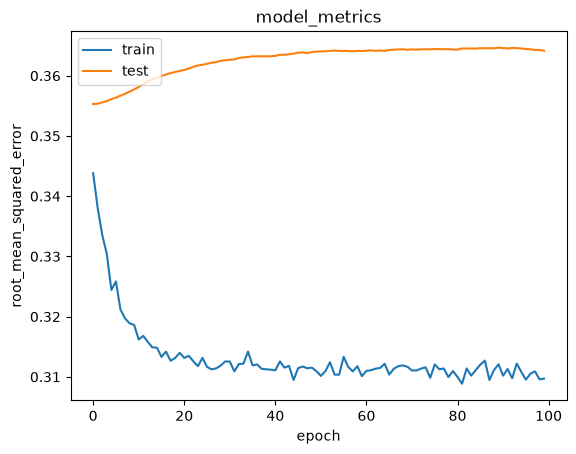

In [71]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [72]:
rating.to_csv('rating_final.csv')

In [83]:
df = pd.read_csv('rating_final.csv')

# Mengambil sample user
user_id = df.User_Id.sample(1).iloc[0]
place_visited_by_user = df[df.User_Id == user_id]

# Operator bitwise (~), bisa diketahui di sini https://docs.python.org/3/reference/expressions.html
place_not_visited = diy_new[
    ~diy_new['Place_Id'].isin(place_visited_by_user.Place_Id.values)
]['Place_Id']
place_not_visited = list(
    set(place_not_visited).intersection(set(place_to_place_encoded.keys()))
)

place_not_visited = [[place_to_place_encoded.get(x)] for x in place_not_visited]
user_encoder = user_to_user_encoded.get(user_id)
user_place_array = np.hstack(
    ([[user_encoder]] * len(place_not_visited), place_not_visited)
)

# 5.Result

In [84]:
ratings = model.predict(user_place_array).flatten()

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_place_ids = [
    place_encoded_to_place.get(place_not_visited[x][0]) for x in top_ratings_indices
]

print('Showing recommendations for users: {}'.format(user_id))
print('===' * 9)
print('Place with high ratings from user')
print('----' * 8)

top_place_user = (
    place_visited_by_user.sort_values(by='Place_Ratings', ascending=False)
    .head(5)
    .Place_Id.values
)

place_df_rpw = diy_new[diy_new['Place_Id'].isin(top_place_user)]
for row in place_df_rpw.itertuples():
    print(row.Place_Name, ':', row.Category)

print('----' * 8)
print('Top 10 place recommendation')
print('----' * 8)

recommended_place = diy_new[diy_new['Place_Id'].isin(recommended_place_ids)]
for row in recommended_place.itertuples():
    print(row.Place_Name, ':', row.Category)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Showing recommendations for users: 234
Place with high ratings from user
--------------------------------
Taman Pelangi Yogyakarta : Taman Hiburan
Embung Tambakboyo : Taman Hiburan
Studio Alam Gamplong : Taman Hiburan
--------------------------------
Top 10 place recommendation
--------------------------------
Sumur Gumuling : Taman Hiburan
Taman Budaya Yogyakarta : Budaya
Bukit Bintang Yogyakarta : Taman Hiburan
Jurang Tembelan Kanigoro : Taman Hiburan
The World Landmarks - Merapi Park Yogyakarta : Taman Hiburan
Watu Goyang : Budaya
Puncak Gunung Api Purba - Nglanggeran : Cagar Alam
Pasar Kebon Empring Bintaran : Pusat Perbelanjaan
Pintoe Langit Dahromo : Cagar Alam
Goa Pindul : Cagar Alam
